# Random Forest for ECG Heartbeat Classification

## 1. Model Objective and Rationale

Random Forest uses the **same 18 engineered ECG features** as Logistic Regression, creating a controlled comparison.

**Research question:** Does nonlinear ensemble modelling improve ECG heartbeat classification compared with the linear Logistic Regression baseline when both models use the same engineered features?

Random Forest can model nonlinear relationships and feature interactions, works well with engineered tabular features, does not require scaling, supports class weighting, and provides feature-importance analysis. It is not fully interpretable.


## 2. Setup and Reproducibility


In [1]:
from pathlib import Path
import json
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)


In [2]:
RANDOM_SEED = 42
CLASS_ORDER = ["N", "S", "V", "F"]
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data" / "processed"
METRICS = ROOT / "results" / "metrics"
PREDICTIONS = ROOT / "results" / "predictions"
MODELS = ROOT / "results" / "models"
FIGURES = ROOT / "figures"
TABLES = ROOT / "report" / "tables"
for folder in [METRICS, PREDICTIONS, MODELS, FIGURES, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)


In [3]:
DROP_COLUMNS = [
    "beat_id", "record_id", "annotation_sample", "annotation_symbol",
    "mapped_class", "split", "selected_lead"
]

def calculate_metrics(y_true, y_pred):
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
    )
    weighted_f1 = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0
    )[2]
    return {"accuracy": accuracy_score(y_true, y_pred),
            "macro_precision": precision, "macro_recall": recall,
            "macro_f1": macro_f1, "weighted_f1": weighted_f1}


In [4]:
setup_table = pd.DataFrame({
    "Setting": ["Model", "Random seed", "Classes", "Number of features",
                "Scaling", "Selection metric", "Class imbalance strategy"],
    "Value": ["Random Forest", RANDOM_SEED, ", ".join(CLASS_ORDER), 18,
              "Not required", "Macro F1", "balanced_subsample"]
})
display(setup_table)


,Setting,Value
0,Model,Random Forest
1,Random seed,42
2,Classes,"N, S, V, F"
3,Number of features,18
4,Scaling,Not required
5,Selection metric,Macro F1
6,Class imbalance strategy,balanced_subsample


## 3. Load Training Data


In [5]:
train = pd.read_csv(DATA / "classical_train.csv", dtype={"record_id": str})
feature_columns = [column for column in train.columns if column not in DROP_COLUMNS]
X_train = train[feature_columns]
y_train = train["mapped_class"].to_numpy()
print("Training shape:", train.shape)
print("Engineered features:", len(feature_columns))


Training shape: (71065, 25)
Engineered features: 18


In [6]:
training_counts = train["mapped_class"].value_counts().reindex(CLASS_ORDER, fill_value=0)
training_distribution = pd.DataFrame({
    "Class": CLASS_ORDER,
    "Training beats": training_counts.values,
    "Percentage": training_counts.values / len(train)
})
display(training_distribution)


,Class,Training beats,Percentage
0,N,63594,0.894871
1,S,2037,0.028664
2,V,5025,0.070710
3,F,409,0.005755


## 4. Load Validation Data


In [7]:
validation = pd.read_csv(DATA / "classical_val.csv", dtype={"record_id": str})
validation_features = [column for column in validation.columns if column not in DROP_COLUMNS]
X_validation = validation[validation_features]
y_validation = validation["mapped_class"].to_numpy()
print("Validation shape:", validation.shape)


Validation shape: (15211, 25)


In [8]:
validation_counts = validation["mapped_class"].value_counts().reindex(CLASS_ORDER, fill_value=0)
validation_distribution = pd.DataFrame({
    "Class": CLASS_ORDER,
    "Validation beats": validation_counts.values,
    "Percentage": validation_counts.values / len(validation)
})
display(validation_distribution)


,Class,Validation beats,Percentage
0,N,13623,0.895602
1,S,310,0.020380
2,V,911,0.059891
3,F,367,0.024127


## 5. Verify Training and Validation Data

Random Forest partitions observations using decision-tree thresholds and therefore does not require feature standardisation. The original engineered feature values are used directly.


In [9]:
data_checks = [
    ["Training rows align with labels", len(X_train) == len(y_train)],
    ["Validation rows align with labels", len(X_validation) == len(y_validation)],
    ["Same feature columns", feature_columns == validation_features],
    ["All feature values finite", np.isfinite(X_train.to_numpy()).all() and np.isfinite(X_validation.to_numpy()).all()],
    ["Classes limited to N/S/V/F", set(y_train).union(y_validation).issubset(CLASS_ORDER)]
]
data_checks_table = pd.DataFrame(data_checks, columns=["Check", "Passed"])
data_checks_table["Result"] = data_checks_table["Passed"].map({True: "PASS", False: "FAIL"})
display(data_checks_table[["Check", "Result"]])


,Check,Result
0,Training rows align with labels,PASS
1,Validation rows align with labels,PASS
2,Same feature columns,PASS
3,All feature values finite,PASS
4,Classes limited to N/S/V/F,PASS


## 6. Majority-Class Baseline


In [10]:
majority_class = pd.Series(y_train).value_counts().idxmax()
baseline_predictions = np.repeat(majority_class, len(y_validation))
baseline_metrics = calculate_metrics(y_validation, baseline_predictions)
baseline_table = pd.DataFrame({
    "Model": ["Majority baseline"],
    "Validation Accuracy": [baseline_metrics["accuracy"]],
    "Validation Macro F1": [baseline_metrics["macro_f1"]]
})
display(baseline_table)


,Model,Validation Accuracy,Validation Macro F1
0,Majority baseline,0.895602,0.236232


## 7. Hyperparameter Search Space

- `n_estimators`: number of trees in the forest.
- `max_depth`: controls how complex each tree can become.
- `min_samples_leaf`: prevents leaves from becoming too specific.
- `max_features`: controls how many features each split considers.
- `balanced_subsample`: recalculates class weights for each bootstrap sample to reduce majority-class dominance.


In [11]:
rf_configurations = [
    {"config_id": "RF1", "n_estimators": 200, "max_depth": None,
     "min_samples_leaf": 1, "max_features": "sqrt"},
    {"config_id": "RF2", "n_estimators": 200, "max_depth": 20,
     "min_samples_leaf": 2, "max_features": "sqrt"},
    {"config_id": "RF3", "n_estimators": 300, "max_depth": 20,
     "min_samples_leaf": 5, "max_features": 0.7}
]
search_space_table = pd.DataFrame(rf_configurations)
search_space_table["class_weight"] = "balanced_subsample"
display(search_space_table)


,config_id,n_estimators,max_depth,min_samples_leaf,max_features,class_weight
0,RF1,200,NaN,1,sqrt,balanced_subsample
1,RF2,200,20.0,2,sqrt,balanced_subsample
2,RF3,300,20.0,5,0.7,balanced_subsample


# 8. Hyperparameter Tuning — Validation Only

> Each candidate Random Forest is trained on the training partition and compared using validation macro F1. The held-out test set is not used in this section.


In [12]:
candidate_results = []
fitted_candidates = []

for configuration in rf_configurations:
    model = RandomForestClassifier(
        n_estimators=configuration["n_estimators"],
        max_depth=configuration["max_depth"],
        min_samples_leaf=configuration["min_samples_leaf"],
        max_features=configuration["max_features"],
        class_weight="balanced_subsample", n_jobs=-1,
        random_state=RANDOM_SEED
    )
    model.fit(X_train, y_train)
    validation_predictions = model.predict(X_validation)
    validation_result = calculate_metrics(y_validation, validation_predictions)
    result = configuration.copy()
    result["class_weight"] = "balanced_subsample"
    result.update(validation_result)
    candidate_results.append(result)
    fitted_candidates.append(model)


In [13]:
candidate_table = pd.DataFrame(candidate_results)
candidate_table = candidate_table.sort_values(
    ["macro_f1", "weighted_f1"], ascending=False
)
best_index = int(candidate_table.index[0])
candidate_table["selected"] = False
candidate_table.loc[best_index, "selected"] = True
display(candidate_table.round(4))


,config_id,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,selected
2,RF3,300,20.0,5,0.7,balanced_subsample,0.9165,0.6001,0.6560,0.6166,0.9260,True
1,RF2,200,20.0,2,sqrt,balanced_subsample,0.9268,0.5474,0.5469,0.5348,0.9232,False
0,RF1,200,NaN,1,sqrt,balanced_subsample,0.9269,0.5174,0.4704,0.4788,0.9155,False


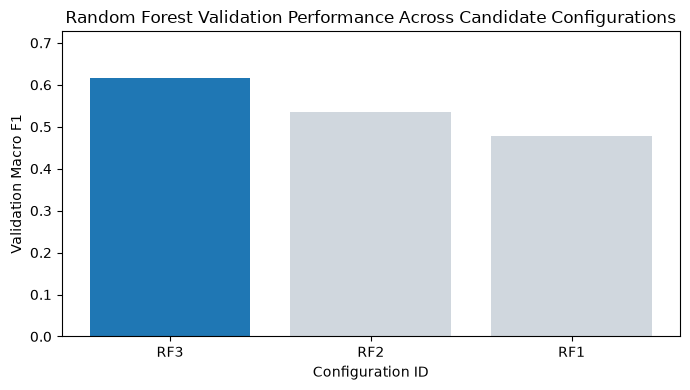

In [14]:
plt.figure(figsize=(7, 4))
bar_colors = ["#D0D7DE" if not value else "#1F77B4" for value in candidate_table["selected"]]
plt.bar(candidate_table["config_id"], candidate_table["macro_f1"], color=bar_colors)
plt.ylabel("Validation Macro F1")
plt.xlabel("Configuration ID")
plt.title("Random Forest Validation Performance Across Candidate Configurations")
plt.ylim(0, max(candidate_table["macro_f1"]) * 1.18)
plt.tight_layout()
plt.savefig(FIGURES / "rf_hyperparameter_validation.png", dpi=200)
plt.show()


## 9. Select and Lock Final Hyperparameters


In [15]:
selected_row = candidate_table.loc[best_index]
selected_configuration = {}
for key in ["n_estimators", "max_depth", "min_samples_leaf", "max_features", "class_weight"]:
    value = selected_row[key]
    if pd.isna(value):
        selected_configuration[key] = None
    elif isinstance(value, np.generic):
        selected_configuration[key] = value.item()
    else:
        selected_configuration[key] = value
for key in ["n_estimators", "max_depth", "min_samples_leaf"]:
    if selected_configuration[key] is not None:
        selected_configuration[key] = int(selected_configuration[key])
selected_configuration["random_state"] = RANDOM_SEED
selected_table = pd.DataFrame(selected_configuration.items(), columns=["Hyperparameter", "Selected value"])
display(selected_table)


,Hyperparameter,Selected value
0,n_estimators,300
1,max_depth,20
2,min_samples_leaf,5
3,max_features,0.7
4,class_weight,balanced_subsample
5,random_state,42


This configuration achieved the selected validation macro F1 and was locked before the test partition was evaluated.


## 10. Train Final Random Forest Model


In [16]:
final_rf = RandomForestClassifier(
    n_estimators=selected_configuration["n_estimators"],
    max_depth=selected_configuration["max_depth"],
    min_samples_leaf=selected_configuration["min_samples_leaf"],
    max_features=selected_configuration["max_features"],
    class_weight=selected_configuration["class_weight"],
    random_state=RANDOM_SEED,
    n_jobs=-1
)


In [17]:
final_rf.fit(X_train, y_train)
print("Final Random Forest fitted on training data only.")


Final Random Forest fitted on training data only.


## 11. Validation Performance


In [18]:
final_validation_predictions = final_rf.predict(X_validation)
validation_metrics = calculate_metrics(y_validation, final_validation_predictions)
validation_metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"],
    "Validation": [validation_metrics["accuracy"], validation_metrics["macro_precision"],
                   validation_metrics["macro_recall"], validation_metrics["macro_f1"],
                   validation_metrics["weighted_f1"]]
})
display(validation_metrics_table.round(4))


,Metric,Validation
0,Accuracy,0.9165
1,Macro Precision,0.6001
2,Macro Recall,0.6560
3,Macro F1,0.6166
4,Weighted F1,0.9260


---

# 12. Held-Out Test Data

**The Random Forest configuration is now locked.**

Training and validation data were used above for model fitting and hyperparameter selection. The held-out test partition is loaded below only for final performance estimation. No hyperparameter is changed after viewing these results.

---


In [19]:
test = pd.read_csv(DATA / "classical_test.csv", dtype={"record_id": str})
test_features = [column for column in test.columns if column not in DROP_COLUMNS]
assert test_features == feature_columns
X_test = test[feature_columns]
y_test = test["mapped_class"].to_numpy()
print("Test shape:", test.shape)


Test shape: (15133, 25)


In [20]:
test_counts = test["mapped_class"].value_counts().reindex(CLASS_ORDER, fill_value=0)
test_distribution = pd.DataFrame({
    "Class": CLASS_ORDER,
    "Test beats": test_counts.values,
    "Percentage": test_counts.values / len(test)
})
display(test_distribution)


,Class,Test beats,Percentage
0,N,13374,0.883764
1,S,434,0.028679
2,V,1299,0.085839
3,F,26,0.001718


## 13. Final Test Evaluation


In [21]:
start_time = time.perf_counter()
test_predictions = final_rf.predict(X_test)
inference_seconds = time.perf_counter() - start_time


In [22]:
test_probabilities_raw = final_rf.predict_proba(X_test)
class_positions = list(final_rf.classes_)
aligned_probabilities = np.column_stack([
    test_probabilities_raw[:, class_positions.index(label)] for label in CLASS_ORDER
])


In [23]:
test_metrics = calculate_metrics(y_test, test_predictions)
test_metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1"],
    "Test": [test_metrics["accuracy"], test_metrics["macro_precision"],
             test_metrics["macro_recall"], test_metrics["macro_f1"],
             test_metrics["weighted_f1"]]
})
display(test_metrics_table.round(4))


,Metric,Test
0,Accuracy,0.8922
1,Macro Precision,0.5044
2,Macro Recall,0.5003
3,Macro F1,0.4979
4,Weighted F1,0.9129


## 14. Per-Class Test Performance


In [24]:
classification = classification_report(
    y_test, test_predictions, labels=CLASS_ORDER,
    output_dict=True, zero_division=0
)
per_class_table = pd.DataFrame(classification).T.loc[CLASS_ORDER]
per_class_table = per_class_table.reset_index().rename(
    columns={"index": "Class", "f1-score": "F1", "support": "Support",
             "precision": "Precision", "recall": "Recall"}
)
display(per_class_table.round(4))


,Class,Precision,Recall,F1,Support
0,N,0.9630,0.9154,0.9386,13374.0
1,S,0.1182,0.1198,0.1190,434.0
2,V,0.9348,0.9276,0.9312,1299.0
3,F,0.0014,0.0385,0.0028,26.0


The model performs strongly for N and V. S remains difficult, while F performance is extremely weak. The F result should not be attributed solely to the algorithm: its test support is extremely small and concentrated in very few records.


## 15. Confusion Matrix


In [25]:
test_confusion = confusion_matrix(y_test, test_predictions, labels=CLASS_ORDER)
confusion_table = pd.DataFrame(test_confusion, index=CLASS_ORDER, columns=CLASS_ORDER)
confusion_table.index.name = "Actual / Predicted"
display(confusion_table)


,N,S,V,F
Actual / Predicted,,,,
N,12243,375,66,690
S,371,52,11,0
V,81,13,1205,0
F,18,0,7,1


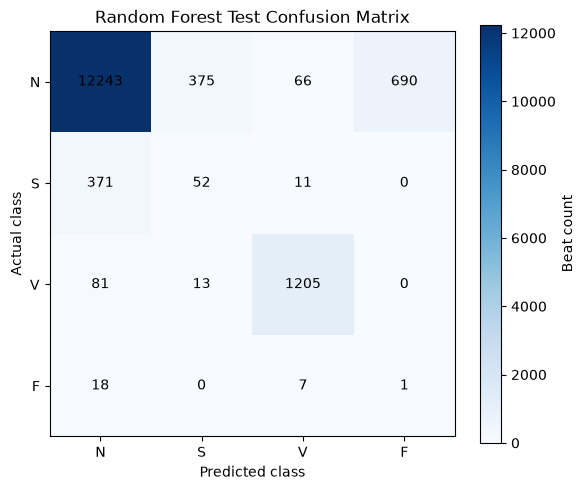

In [26]:
plt.figure(figsize=(6, 5))
plt.imshow(confusion_table.to_numpy(), cmap="Blues")
plt.colorbar(label="Beat count")
for row in range(len(CLASS_ORDER)):
    for column in range(len(CLASS_ORDER)):
        value = confusion_table.iloc[row, column]
        plt.text(column, row, str(value), ha="center", va="center")
plt.xticks(range(len(CLASS_ORDER)), CLASS_ORDER)
plt.yticks(range(len(CLASS_ORDER)), CLASS_ORDER)
plt.title("Random Forest Test Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.savefig(FIGURES / "rf_confusion_matrix.png", dpi=200)
plt.show()


## 16. Feature Importance

Permutation importance measures the reduction in validation macro F1 when a feature is randomly shuffled. Larger decreases indicate greater predictive importance to the fitted RF model.

A fixed validation subsample of 5,000 observations is used to keep repeated permutation evaluation computationally manageable while preserving reproducibility. Importance is predictive, not causal physiology.


In [27]:
importance_sample_size = min(5000, len(X_validation))
importance_rng = np.random.default_rng(RANDOM_SEED)
importance_indices = importance_rng.choice(
    len(X_validation), importance_sample_size, replace=False
)
importance_result = permutation_importance(
    final_rf, X_validation.iloc[importance_indices], y_validation[importance_indices],
    scoring="f1_macro", n_repeats=5, random_state=RANDOM_SEED, n_jobs=-1
)


In [28]:
importance_table = pd.DataFrame({
    "Feature": feature_columns,
    "Mean Importance": importance_result.importances_mean,
    "Std Importance": importance_result.importances_std
})
importance_table = importance_table.sort_values("Mean Importance", ascending=False).reset_index(drop=True)
importance_table.insert(0, "Rank", np.arange(1, len(importance_table) + 1))
top_features_table = importance_table.head(10).copy()
display(importance_table.round(6))


,Rank,Feature,Mean Importance,Std Importance
0,1,rr_previous_s,0.135287,0.007382
1,2,max_abs_slope,0.087839,0.014420
2,3,rr_next_s,0.069950,0.013025
3,4,rr_local_mean_s,0.065719,0.005598
4,5,qrs_local_range,0.045062,0.006073
5,6,mean_abs_slope,0.035513,0.006364
6,7,wave_max,0.031835,0.011810
7,8,wave_min,0.029794,0.002256
8,9,rr_previous_relative,0.029077,0.007020
9,10,wave_median,0.026570,0.005165


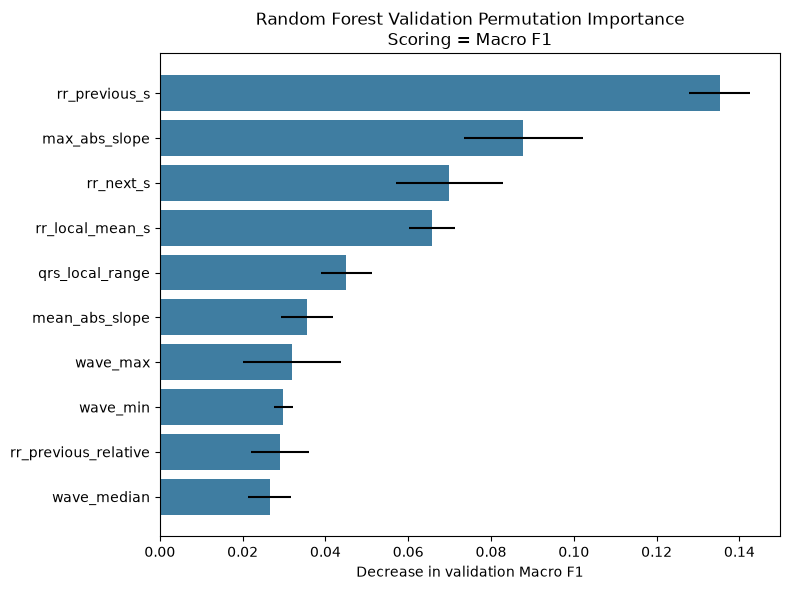

In [29]:
plot_table = top_features_table.sort_values("Mean Importance")
plt.figure(figsize=(8, 6))
plt.barh(plot_table["Feature"], plot_table["Mean Importance"],
         xerr=plot_table["Std Importance"], color="#2A6F97", alpha=0.9)
plt.xlabel("Decrease in validation Macro F1")
plt.title("Random Forest Validation Permutation Importance\nScoring = Macro F1")
plt.tight_layout()
plt.savefig(FIGURES / "rf_permutation_importance.png", dpi=200)
plt.show()


Random Forest uses the same engineered ECG features as Logistic Regression, so the comparison isolates the effect of using a nonlinear ensemble rather than a linear classifier. The improvement in validation/test macro F1 suggests that nonlinear feature relationships may provide useful information, although the final cross-model conclusion is evaluated in Notebook 06.


## 17. Validation vs Test Comparison


In [30]:
comparison_rows = []
metric_labels = [("Accuracy", "accuracy"), ("Macro Precision", "macro_precision"),
                 ("Macro Recall", "macro_recall"), ("Macro F1", "macro_f1"),
                 ("Weighted F1", "weighted_f1")]
for label, key in metric_labels:
    validation_value = validation_metrics[key]
    test_value = test_metrics[key]
    comparison_rows.append([label, validation_value, test_value, test_value - validation_value])
validation_test_table = pd.DataFrame(
    comparison_rows, columns=["Metric", "Validation", "Test", "Change"]
)
display(validation_test_table.round(4))


,Metric,Validation,Test,Change
0,Accuracy,0.9165,0.8922,-0.0244
1,Macro Precision,0.6001,0.5044,-0.0957
2,Macro Recall,0.6560,0.5003,-0.1556
3,Macro F1,0.6166,0.4979,-0.1187
4,Weighted F1,0.9260,0.9129,-0.0132


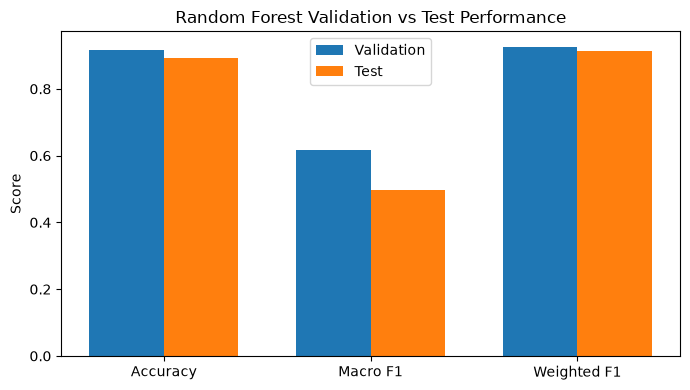

In [31]:
plot_metrics = validation_test_table[
    validation_test_table["Metric"].isin(["Accuracy", "Macro F1", "Weighted F1"])
]
x_positions = np.arange(len(plot_metrics))
plt.figure(figsize=(7, 4))
plt.bar(x_positions - 0.18, plot_metrics["Validation"], 0.36, label="Validation")
plt.bar(x_positions + 0.18, plot_metrics["Test"], 0.36, label="Test")
plt.xticks(x_positions, plot_metrics["Metric"])
plt.ylabel("Score")
plt.title("Random Forest Validation vs Test Performance")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "rf_validation_vs_test.png", dpi=200)
plt.show()


## 18. Save Model and Results


In [32]:
model_path = MODELS / "random_forest.joblib"
joblib.dump(final_rf, model_path)
print("Saved:", model_path.relative_to(ROOT))


Saved: results\models\random_forest.joblib


In [33]:
prediction_output = test[["beat_id", "record_id", "mapped_class"]].copy()
prediction_output = prediction_output.rename(columns={"mapped_class": "true_class"})
prediction_output["predicted_class"] = test_predictions
for position, label in enumerate(CLASS_ORDER):
    prediction_output[f"probability_{label}"] = aligned_probabilities[:, position]
prediction_path = PREDICTIONS / "random_forest_test_predictions.csv"
prediction_output.to_csv(prediction_path, index=False)


In [34]:
metrics_payload = {
    "model": "Random Forest",
    "selected": {key: value for key, value in selected_configuration.items() if key != "random_state"},
    "validation": validation_metrics,
    "test": test_metrics,
    "test_inference_seconds": inference_seconds
}
metrics_path = METRICS / "random_forest_metrics.json"
metrics_path.write_text(json.dumps(metrics_payload, indent=2))


664

In [35]:
candidate_save = candidate_table.drop(columns=["config_id"])
candidate_path = METRICS / "random_forest_candidates_validation.csv"
candidate_save.to_csv(candidate_path, index=False)

per_class_save = pd.DataFrame(classification).T
per_class_path = METRICS / "random_forest_test_per_class.csv"
per_class_save.to_csv(per_class_path)


In [36]:
importance_save = importance_table.rename(columns={
    "Feature": "feature", "Mean Importance": "permutation_importance_mean",
    "Std Importance": "permutation_importance_std"
}).drop(columns=["Rank"])
importance_path = METRICS / "random_forest_permutation_importance.csv"
importance_save.to_csv(importance_path, index=False)


In [37]:
saved_artifacts_table = pd.DataFrame([
    ["Model", model_path.relative_to(ROOT), "Locked RF model"],
    ["Predictions", prediction_path.relative_to(ROOT), "Held-out test predictions"],
    ["Metrics", metrics_path.relative_to(ROOT), "Final RF metrics"],
    ["Candidate results", candidate_path.relative_to(ROOT), "Validation tuning evidence"],
    ["Permutation importance", importance_path.relative_to(ROOT), "Feature interpretation"]
], columns=["Artifact", "Relative path", "Purpose"])
saved_artifacts_table["Relative path"] = saved_artifacts_table["Relative path"].astype(str)
display(saved_artifacts_table)


,Artifact,Relative path,Purpose
0,Model,results\models\random_forest.joblib,Locked RF model
1,Predictions,results\predictions\random_forest_test_predict...,Held-out test predictions
2,Metrics,results\metrics\random_forest_metrics.json,Final RF metrics
3,Candidate results,results\metrics\random_forest_candidates_valid...,Validation tuning evidence
4,Permutation importance,results\metrics\random_forest_permutation_impo...,Feature interpretation


## 19. Integrity Checks


In [38]:
reloaded_rf = joblib.load(model_path)
integrity_checks = [
    ["Training/validation separated", True], ["Test excluded from tuning", True],
    ["Same 18 feature columns used", len(feature_columns) == 18 and test_features == feature_columns],
    ["No feature scaling applied", True],
    ["Selected configuration matches validation winner", best_index == int(candidate_table.index[0])],
    ["Test probabilities sum approximately to 1", np.allclose(aligned_probabilities.sum(axis=1), 1, atol=1e-6)],
    ["Predictions align with labels", len(test_predictions) == len(y_test)],
    ["Saved RF model reloads", np.array_equal(reloaded_rf.predict(X_test), test_predictions)],
    ["Permutation importance uses validation data only", len(importance_indices) == importance_sample_size]
]
integrity_checks_table = pd.DataFrame(integrity_checks, columns=["Check", "Passed"])
integrity_checks_table["Result"] = integrity_checks_table["Passed"].map({True: "PASS", False: "FAIL"})
display(integrity_checks_table[["Check", "Result"]])


,Check,Result
0,Training/validation separated,PASS
1,Test excluded from tuning,PASS
2,Same 18 feature columns used,PASS
3,No feature scaling applied,PASS
4,Selected configuration matches validation winner,PASS
5,Test probabilities sum approximately to 1,PASS
6,Predictions align with labels,PASS
7,Saved RF model reloads,PASS
8,Permutation importance uses validation data only,PASS


## 20. Report-Ready Tables


In [39]:
report_index = pd.DataFrame([
    ["Setup", "RF_setup.xlsx", "Task 2"],
    ["Hyperparameter search", "RF_hyperparameter_results.xlsx", "Task 2"],
    ["Selected parameters", "RF_selected_hyperparameters.xlsx", "Task 2"],
    ["Validation/test comparison", "RF_validation_vs_test.xlsx", "Task 3"],
    ["Per-class results", "RF_test_per_class_metrics.xlsx", "Task 3"],
    ["Top feature importance", "RF_top_features.xlsx", "Task 3"]
], columns=["Table", "Excel file", "Suggested report use"])
display(report_index)


,Table,Excel file,Suggested report use
0,Setup,RF_setup.xlsx,Task 2
1,Hyperparameter search,RF_hyperparameter_results.xlsx,Task 2
2,Selected parameters,RF_selected_hyperparameters.xlsx,Task 2
3,Validation/test comparison,RF_validation_vs_test.xlsx,Task 3
4,Per-class results,RF_test_per_class_metrics.xlsx,Task 3
5,Top feature importance,RF_top_features.xlsx,Task 3


## 21. Random Forest Summary


In [40]:
strongest_class = per_class_table.sort_values("F1", ascending=False).iloc[0]
summary_table = pd.DataFrame({
    "Item": ["Model", "Input", "Scaling", "Class weighting", "Selected trees",
             "Selected max depth", "Validation accuracy", "Validation macro F1",
             "Test accuracy", "Test macro F1", "Strongest class result", "Main limitation"],
    "Result": ["Random Forest", "18 engineered ECG features", "Not required",
               "balanced_subsample", selected_configuration["n_estimators"],
               selected_configuration["max_depth"], validation_metrics["accuracy"],
               validation_metrics["macro_f1"], test_metrics["accuracy"],
               test_metrics["macro_f1"],
               f'{strongest_class["Class"]} F1 = {strongest_class["F1"]:.4f}',
               "Weak S and F performance; F has very small, record-concentrated support"]
})
display(summary_table)


,Item,Result
0,Model,Random Forest
1,Input,18 engineered ECG features
2,Scaling,Not required
3,Class weighting,balanced_subsample
4,Selected trees,300
5,Selected max depth,20
6,Validation accuracy,0.916508
7,Validation macro F1,0.616595
8,Test accuracy,0.892156
9,Test macro F1,0.497908


The Random Forest improves on the linear baseline while using the same 18 engineered inputs. Its strongest results occur for the common N class and the clinically important V class. Performance falls from validation to test, especially for macro F1, and minority S/F recognition remains a limitation. Permutation importance supports model interpretation but does not demonstrate causal physiology.
